# Deep Learning Diabetes Regression (Glucose Prediction)

이 노트북은 `wine_dl_regression.ipynb` 샘플 코드를 참고하여 `diabetes.csv` 데이터의 여러 특성을 바탕으로 포도당 수치(`Glucose`)를 예측하는 회귀 모델을 구현합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [14]:
# 1. 데이터 로드
df = pd.read_csv('csv/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33,0,50,1
1,1,85,66,29,0,26,0,31,0
2,8,183,64,0,0,23,0,32,1
3,1,89,66,23,94,28,0,21,0
4,0,137,40,35,168,43,2,33,1


In [4]:
# 2. 데이터 전처리 (회귀용)
# 목표(y): 'Glucose' (연속적인 수치)
# 피처(X): 'Glucose'를 제외한 모든 컬럼
X = df.drop('Glucose', axis=1)
y = df['Glucose']

# 피처 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0
)

In [5]:
# 3. 모델 구축 (회귀 모델)
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1) # 출력 노드는 1개, 활성화 함수 없음
])

# 4. 모델 컴파일
model.compile(
    optimizer="adam",
    loss="mse",      # 손실 함수로 MSE 사용
    metrics=["mae"]  # 평가 지표로 MAE 사용
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 5. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 15727.5293 - mae: 121.2365 - val_loss: 14353.1719 - val_mae: 115.9976
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15275.5820 - mae: 119.4055 - val_loss: 13854.2236 - val_mae: 113.8578
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14572.3174 - mae: 116.4785 - val_loss: 12967.1172 - val_mae: 109.9633
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13338.8975 - mae: 111.1817 - val_loss: 11457.9971 - val_mae: 103.0109
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11350.5234 - mae: 102.0240 - val_loss: 9187.8574 - val_mae: 91.5155
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8640.0098 - mae: 88.1360 - val_loss: 6411.4526 - val_mae: 74.8799
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5684.3848 - mae: 69.6001 - val_loss: 3798.1270 - val_mae: 54.7680
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3276.9648 - mae: 50.0951 - val_loss: 2075.2932 -

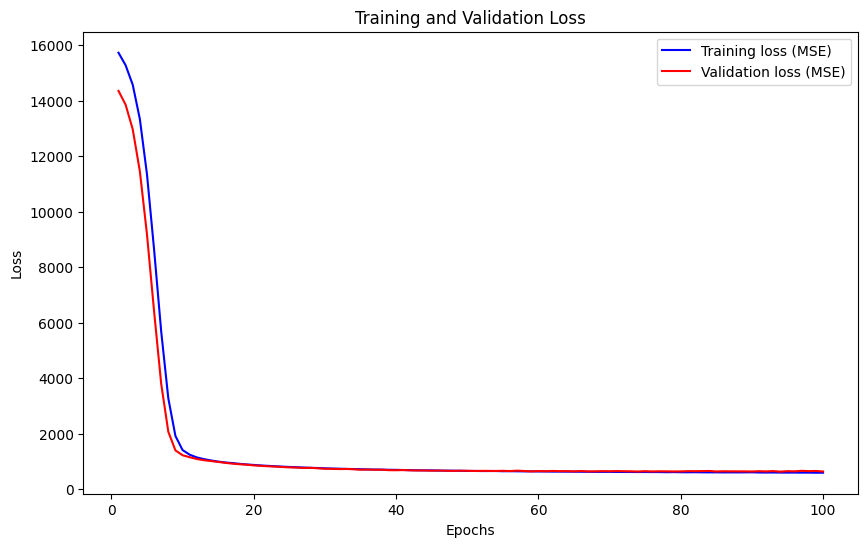

In [7]:
# 6. 학습 곡선 시각화
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'b', label='Training loss (MSE)')
plt.plot(epochs, val_loss, 'r', label='Validation loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [8]:
# 7. 예측 및 성능 평가
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Mean Squared Error (MSE): 753.7495
Mean Absolute Error (MAE): 20.8535
R2 Score: 0.2913


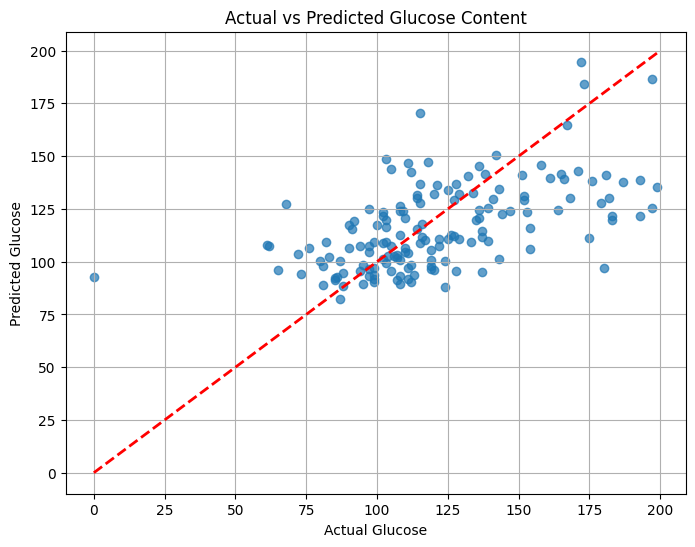

In [9]:
# 8. 실제값 vs 예측값 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Glucose')
plt.ylabel('Predicted Glucose')
plt.title('Actual vs Predicted Glucose Content')
plt.grid(True)
plt.show()